In [16]:
# Header for the notebook
from datetime import datetime
from IPython.display import display, Markdown

# Get the current date
title = "Movement Analysis Project (2025-2026)"
current_date = datetime.now().strftime("%d %B %Y, %H:%M:%S")
authors = "ABDEL-HAMID Chahine"

# Insert the date into the notebook
display(Markdown(f"# {title}"))
display(Markdown(f"{current_date}"))
display(Markdown(f"by {authors}"))

# Movement Analysis Project (2025-2026)

23 April 2026, 10:08:13

by ABDEL-HAMID Chahine

# Cleaning of the Data 



In [11]:
import os
import pandas as pd

data_folder = "data"

def read_clean_df(file_path):
    df = pd.read_excel(file_path, header=None)

    # Trouver la ligne où il y a "Name"
    header_row = df[df.apply(lambda row: row.astype(str).str.contains("Name").any(), axis=1)].index[0]

    # Recréer le dataframe avec les bons headers
    df.columns = df.iloc[header_row]
    df = df.iloc[header_row + 1:].reset_index(drop=True)

    return df

data = []

for patient in os.listdir(data_folder):
    patient_path = os.path.join(data_folder, patient)

    if not os.path.isdir(patient_path):
        continue

    values = {"SJ_Mean": None, "CMJ_Mean": None}

    for file in ["SJ.xlsx", "CMJ.xlsx"]:
        file_path = os.path.join(patient_path, file)

        if not os.path.exists(file_path):
            continue

        try:
            df = read_clean_df(file_path)

            row = df[df["Name"] == "Jump Height (Flight Time) [cm]"]
            mean_value = float(row["Mean"].values[0])

            if file == "SJ.xlsx":
                values["SJ_Mean"] = mean_value
            else:
                values["CMJ_Mean"] = mean_value

        except Exception as e:
            print(f"{patient} - {file} : erreur -> {e}")

    data.append({
        "Patient": patient,
        "SJ_Mean": values["SJ_Mean"],
        "CMJ_Mean": values["CMJ_Mean"]
    })

df_final = pd.DataFrame(data)

output_path = os.path.join(data_folder, "Global_Jump_Height.xlsx")
df_final.to_excel(output_path, index=False)

# Plotting of the Results for the Visual Analysis

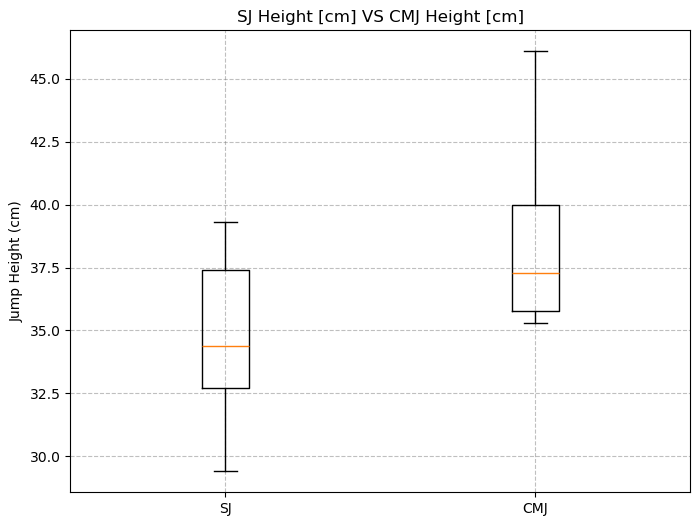

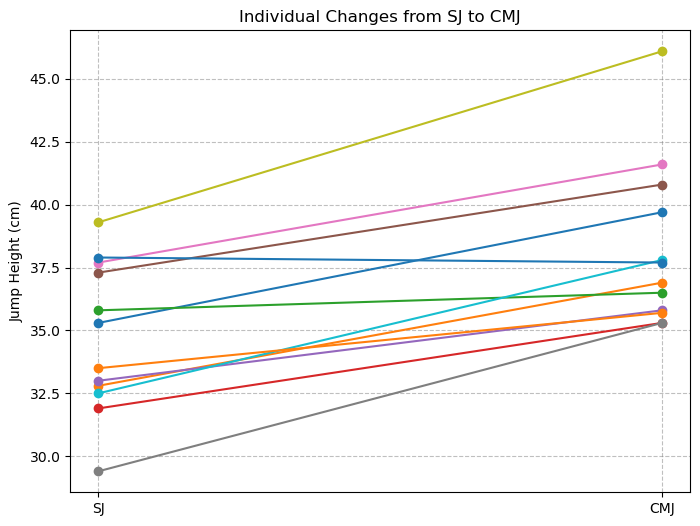

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

# Lire le fichier final créé après nettoyage
df = pd.read_excel("data/Global_Jump_Height.xlsx")

# ----- BOXPLOT -----
plt.figure(figsize=(8, 6))
plt.boxplot([df["SJ_Mean"], df["CMJ_Mean"]], tick_labels=["SJ", "CMJ"])
plt.ylabel("Jump Height (cm)")
plt.title("SJ Height [cm] VS CMJ Height [cm]")
plt.grid(color='grey', linestyle='--', alpha=0.5)
plt.show()

# ----- PAIRED PLOT -----
plt.figure(figsize=(8,6))

for i in range(len(df)):
    plt.plot(
        ["SJ", "CMJ"],
        [df.iloc[i]["SJ_Mean"], df.iloc[i]["CMJ_Mean"]],
        marker="o"
    )

plt.ylabel("Jump Height (cm)")
plt.title("Individual Changes from SJ to CMJ")
plt.grid(color='grey', linestyle='--', alpha=0.5)
plt.show()

In [13]:
# https://nbconvert.readthedocs.io/en/latest/removing_cells.html

# https://github.com/msm1089/ipynbname/issues/17#issuecomment-1293269863


from traitlets.config import Config
from nbconvert.exporters import HTMLExporter
from nbconvert.preprocessors import TagRemovePreprocessor
from IPython import get_ipython


def get_notebook_name():
    """
    Get the current notebook name (without extension).
    """
    ip = get_ipython()
    path = None
    if "__vsc_ipynb_file__" in ip.user_ns:
        path = ip.user_ns["__vsc_ipynb_file__"]

    return path.split("/")[-1].split(".")[0]


# Get the notebook name
notebook_file_name = get_notebook_name()


# Setup config
c = Config()

# Configure tag removal - be sure to tag your cells to remove  using the
# words remove_cell to remove cells. You can also modify the code to use
# a different tag word
c.TagRemovePreprocessor.remove_cell_tags = ("remove",)
c.TagRemovePreprocessor.remove_all_outputs_tags = ("remove_output",)
c.TagRemovePreprocessor.remove_input_tags = ("hide",)
c.TagRemovePreprocessor.enabled = True
c.HTMLExporter.preprocessors = ["nbconvert.preprocessors.TagRemovePreprocessor"]

# ensure the graphics are included in the html
c.HTMLExporter.embed_images = True
# do not show the input code cells (distracts from the output)
c.HTMLExporter.exclude_output_prompt = True
c.HTMLExporter.exclude_input_prompt = True

# Configure the exporter
exporter = HTMLExporter(config=c)
exporter.register_preprocessor(TagRemovePreprocessor(config=c), True)


# run our exporter - returns a tuple - first element with html,
# second with notebook metadata
output = HTMLExporter(config=c).from_filename(notebook_file_name + ".ipynb")

# Write to output html file
with open(notebook_file_name + ".html", "w") as f:
    f.write(output[0])

# open the file with the operating system
import os

# if osx use open, if linux use xdg-open, if windows use start
try:
    if os.name == "posix":
        if os.uname().sysname == "Darwin":
            # macOS
            errorCode = os.system("open " + notebook_file_name + ".html")
        else:
            # Linux
            errorCode = os.system("xdg-open " + notebook_file_name + ".html")
    elif os.name == "nt":
        # Windows
        errorCode = os.system("start " + notebook_file_name + ".html")
    else:
        print("Unsupported OS")
except Exception as e:
    print("Error opening file: ", e)